# Lab: Decision Trees

---

## 1. Introduction

In this lab, we will use a Decision Tree to solve a multi-class classification problem. We'll take on the role of a medical researcher to build a model that recommends one of five possible drugs for a patient based on their health profile.

* **Goal:** To build a Decision Tree model that can predict the appropriate drug for a patient.
* **Data:** The "Drug Classification" dataset, which contains patient data and the drug that was effective for each one.
* **Key Concepts:** We will focus on data preprocessing for tree models, training the classifier, evaluating its performance, and -most importantly- visualizing and interpreting the resulting tree.

---

## 2. Setup and Data Loading
First, let's import the necessary libraries.

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
# Load the data from the URL
path = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
df = pd.read_csv(path)

# Display a sample from the data
df.sample(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
177,25,M,NORMAL,HIGH,19.011,drugY
109,23,M,NORMAL,HIGH,16.850,drugY
171,45,M,LOW,NORMAL,10.017,drugX
48,23,M,NORMAL,HIGH,31.686,drugY
12,43,M,LOW,HIGH,15.376,drugY


In [5]:
# General information on the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB



---

## 3. Data Preprocessing and Exploration

Decision Trees can handle a mix of data types, but the features still need to be in a numerical format for `scikit-learn`.

#### 3.1. Convert Categorical Features to Numerical
Our dataset contains three categorical features: `Sex`, `BP` (Blood Pressure), and `Cholesterol`. We need to convert these text-based categories into numbers. For tree-based models, a simple `LabelEncoder` is often sufficient. It assigns a unique integer to each category.

In [7]:
# Create a LabelEncoder object
le = LabelEncoder()

# Apply the encoder to each categorical column
df['Sex'] = le.fit_transform(df['Sex'])
df['BP'] = le.fit_transform(df['BP'])
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])

# Display the data to see the changes
# F=0, M=1 | HIGH=0, LOW=1, NORMAL=2 | HIGH=0, NORMAL=1
df.sample(5)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
102,28,0,1,0,13.127,drugC
149,22,1,1,0,8.151,drugC
133,24,1,2,0,25.786,drugY
9,43,1,1,1,19.368,drugY
24,33,0,1,0,33.486,drugY


#### 3.2. Exploratory Data Analysis
Let's check the distribution of our target variable, `Drug`, to see if the classes are balanced.

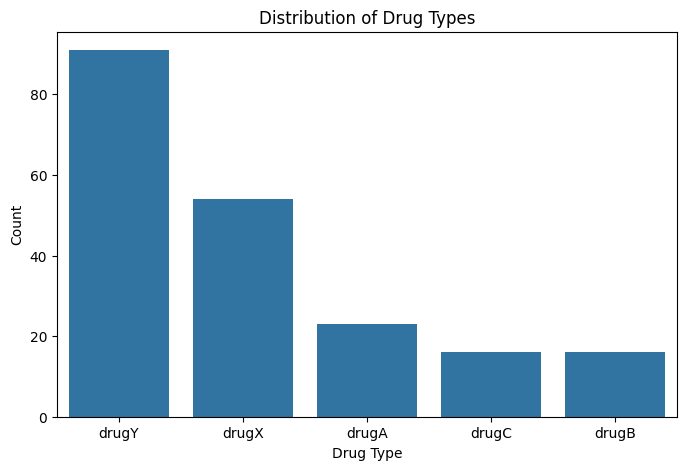

In [9]:
# Visualize the distribution of the target variable
plt.figure(figsize=(8, 5))
sns.countplot(df, x='Drug', order=df['Drug'].value_counts().index)
plt.title("Distribution of Drug Types")
plt.xlabel("Drug Type")
plt.ylabel("Count")
plt.show()

> 🔍 **Observation:**  
> The dataset is imbalanced. "DrugY" has the most samples, while "DrugB" has the fewest. This is important to keep in mind when we evaluate our model. Accuracy alone might not be the best metric.

---

## 4. Model Training

Now we're ready to build our Decision Tree.

#### 4.1. Separate Features (X) and Target (y)

In [12]:
# X contains our independent features
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']]

# y contains our target variable
y = df['Drug']  

#### 4.2. Split Data into Training and Test Sets